# **Sentiment Analysis Simobi+ Bank Sinarmas.ipynb**

## Load Dataset

In [1]:
import pandas as pd

reviews_df = pd.read_csv("../data/reviews_simobi.csv")

In [2]:
print(reviews_df.info())

reviews_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 16802 entries, 0 to 16801
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   content  16802 non-null  str  
dtypes: str(1)
memory usage: 131.4 KB
None


,content
0,terbaik
1,"masih banyak bug, notif error muncul terus, ma..."
2,"pelayanan kurang baik ,perlu jawaban mengenai ..."
3,fitur lengkappp
4,good


## Preprocessing

### Requirement

In [3]:
%pip install sastrawi emoji nltk


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Cleaning Text

In [4]:
import re

def cleaning_text(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'@[\w.]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\bRT\b', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = text.replace('\n', ' ')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

### Convert Emoji

In [5]:
import emoji

def convert_emoji(text):
    text = str(text)
    out, prev = [], None
    for ch in text:
        if emoji.is_emoji(ch) and ch == prev:
            continue
        out.append(ch)
        prev = ch
    text = ''.join(out)
    text = emoji.demojize(text, language='id')
    return text.replace(':', ' ').replace('_', ' ').replace('-', ' ')

### Case Folding

In [6]:
def case_folding_text(text):
    return str(text).lower()

### Normalize Elongation

In [7]:
def normalize_elongation(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

### Fix Slangwords

In [8]:
slang_words_df = pd.read_csv("../data/slang_words.csv")

slangwords = dict(zip(
    slang_words_df.iloc[:, 0].astype(str).str.lower(),
    slang_words_df.iloc[:, 1].astype(str)
))

slangwords.update({
    'ngomong': 'bicara', 'ngomongnya': 'bicara', 'dr': 'dari',
    'terimakasih': 'terima kasih', 'makasih': 'terima kasih',
    'mksh': 'terima kasih', 'thanks': 'terima kasih',
    'terimakaaih': 'terima kasih'
    })

slang_pattern = re.compile(
    r'\b(?:' + '|'.join(re.escape(s) for s in slangwords) + r')\b'
)

def fix_slangwords(text):
    text = str(text).lower()
    return slang_pattern.sub(lambda m: slangwords[m.group(0)], text)

### Tokenizing

In [9]:
import nltk

from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

def tokenizing_text(text):
    return word_tokenize(str(text))

[nltk_data] Downloading package punkt to /Users/maulana/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maulana/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maulana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Stopwords

In [10]:
from nltk.corpus import stopwords


listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(stopwords.words('english'))

listStopwords.update([
    'iya', 'yaa', 'gak', 'nya', 'na', 'sih', 'ku', 'di', 'ga', 'ya', 'gaa',
    'loh', 'kah', 'woi', 'woii', 'woy', 'lah', 'god', 'wkwk', 'wkwkwk',
    'komen', 'sticker', 'buu', 'masing', 'aja',
])

listStopwords.update([
    'aplikasi', 'simobi', 'update', 'versi', 'bank',
    'google', 'play', 'store', 'android', 'hp',
])

for neg in ['tidak', 'bukan', 'jangan', 'belum', 'tak', 'kurang', 'gak', 'ga', 'enggak', 'nggak', 'gk']:
    listStopwords.discard(neg)


def filtering_stopwords(text):
    return [word for word in text if word not in listStopwords and len(word) > 1]

### To Sentence

In [11]:
def to_sentence(tokens):
    return ' '.join(tokens)

### Pipeline

In [12]:
df = reviews_df.copy()

df["text_emoji"] = df["content"].apply(convert_emoji)
df["text_clean"] = df["text_emoji"].apply(cleaning_text)
df = df[df["text_clean"].str.strip() != ""].reset_index(
    drop=True
)

df["text_case_folding"] = df["text_clean"].apply(case_folding_text)
df["text_elongation"] = df["text_case_folding"].apply(
    normalize_elongation
)
df["text_slangwords"] = df["text_elongation"].apply(fix_slangwords)
df["text_tokenizing"] = df["text_slangwords"].apply(tokenizing_text)
df["text_stopword"] = df["text_tokenizing"].apply(filtering_stopwords)
df = df[df["text_stopword"].apply(len) > 0].reset_index(
    drop=True
)

In [13]:
from tqdm import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


stemmer = StemmerFactory().create_stemmer()
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())

for neg in [
    "tidak",
    "bukan",
    "jangan",
    "belum",
    "tak",
    "kurang",
    "gak",
    "ga",
    "enggak",
    "nggak",
    'gk'
]:
    sastrawi_sw.discard(neg)

for word in ["ok", "tolong"]:
    sastrawi_sw.discard(word)

vocab = set(w for toks in df['text_stopword'] for w in toks)
stem_cache: dict[str, str] = {w: stemmer.stem(w) for w in tqdm(vocab)}
stem_corrections: dict[str, str] = {"bagu": "bagus"}


def stemming_text(tokens: list[str]) -> list[str]:
    stemmed = [stem_cache.get(w, w) for w in tokens]
    return [stem_corrections.get(w, w) for w in stemmed]


df['text_stemmed'] = df['text_stopword'].apply(stemming_text)

df["text_stemmed"] = df["text_stemmed"].apply(
    lambda toks: [w for w in toks if w not in sastrawi_sw]
)

df['text_finally_clean'] = df['text_stemmed'].apply(to_sentence)

df = df[df['text_stemmed'].apply(len) >= 2].reset_index(drop=True)
df = df[df['text_finally_clean'].str.strip() != ''].reset_index(drop=True)
df = df.drop_duplicates(subset=['text_finally_clean']).reset_index(drop=True)

df.to_pickle('../bin/preprocessed_result.pkl')
df.head()

100%|██████████| 10670/10670 [05:07<00:00, 34.73it/s]


,content,text_emoji,text_clean,text_case_folding,text_elongation,text_slangwords,text_tokenizing,text_stopword,text_stemmed,text_finally_clean
0,"masih banyak bug, notif error muncul terus, ma...","masih banyak bug, notif error muncul terus, ma...",masih banyak bug notif error muncul terus mau ...,masih banyak bug notif error muncul terus mau ...,masih banyak bug notif error muncul terus mau ...,masih banyak bug notif error muncul terus mau ...,"[masih, banyak, bug, notif, error, muncul, ter...","[bug, notif, error, muncul, perbaiki, data, al...","[bug, notif, error, muncul, baik, data, alamat...",bug notif error muncul baik data alamat error ...
1,"pelayanan kurang baik ,perlu jawaban mengenai ...","pelayanan kurang baik ,perlu jawaban mengenai ...",pelayanan kurang baik perlu jawaban mengenai k...,pelayanan kurang baik perlu jawaban mengenai k...,pelayanan kurang baik perlu jawaban mengenai k...,pelayanan kurang baik perlu jawaban mengenai k...,"[pelayanan, kurang, baik, perlu, jawaban, meng...","[pelayanan, kurang, keluhan, level, prioritas,...","[layan, kurang, keluh, level, prioritas, laen,...",layan kurang keluh level prioritas laen cs sin...
2,fitur lengkappp,fitur lengkappp,fitur lengkappp,fitur lengkappp,fitur lengkapp,fitur lengkapp,"[fitur, lengkapp]","[fitur, lengkapp]","[fitur, lengkapp]",fitur lengkapp
3,sanabgat baik dan membantu,sanabgat baik dan membantu,sanabgat baik dan membantu,sanabgat baik dan membantu,sanabgat baik dan membantu,sanabgat baik dan membantu,"[sanabgat, baik, dan, membantu]","[sanabgat, membantu]","[sanabgat, bantu]",sanabgat bantu
4,bagus..cuman aplikasiya masuk pertama tanpa kunci,bagus..cuman aplikasiya masuk pertama tanpa kunci,bagus cuman aplikasiya masuk pertama tanpa kunci,bagus cuman aplikasiya masuk pertama tanpa kunci,bagus cuman aplikasiya masuk pertama tanpa kunci,bagus cuman aplikasiya masuk pertama tanpa kunci,"[bagus, cuman, aplikasiya, masuk, pertama, tan...","[bagus, cuman, aplikasiya, masuk, kunci]","[bagus, cuman, aplikasiya, masuk, kunci]",bagus cuman aplikasiya masuk kunci


## Labeling

### Lexicon Label

In [14]:
%pip install requests


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
import csv
import requests
from io import StringIO

LEXICON_POS_PATH = "../data/lexicon_positive.csv"
LEXICON_NEG_PATH = "../data/lexicon_negative.csv"


def load_lexicon(path, url):
    if os.path.exists(path):
        with open(path, newline="", encoding="utf-8") as f:
            return {row[0]: int(row[1]) for row in csv.reader(f)}

    response = requests.get(url)
    if response.status_code != 200:
        raise RuntimeError(f"Failed to fetch {url}")

    with open(path, "w", newline="", encoding="utf-8") as f:
        f.write(response.text)

    return {row[0]: int(row[1]) for row in csv.reader(StringIO(response.text))}


lexicon_positive = load_lexicon(
    LEXICON_POS_PATH,
    "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv",
)
lexicon_negative = load_lexicon(
    LEXICON_NEG_PATH,
    "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv",
)

print(f"Positive: {len(lexicon_positive)} kata")
print(f"Negative: {len(lexicon_negative)} kata")

Positive: 3609 kata
Negative: 6607 kata


In [16]:
negations = {"tidak", "bukan", "jangan", "belum", "tak", "gak", "ga", "nggak", "enggak", 'gk'}
diminishers = {"kurang"}


def lexicon_label(tokens):
    score = 0
    for i, word in enumerate(tokens):
        val = lexicon_positive.get(word, 0) + lexicon_negative.get(word, 0)
        if val != 0 and i > 0:
            prev_words = tokens[max(0, i - 2) : i]
            if any(w in negations for w in prev_words):
                val = -val
            elif tokens[i - 1] in diminishers:
                val = val * 0.5
        score += val

    if score > 0:
        polarity = "positive"
    elif score < 0:
        polarity = "negative"
    else:
        polarity = "neutral"

    return score, polarity

In [17]:
result = df['text_stemmed'].apply(lexicon_label)
df['polarity_score'] = result.apply(lambda x: x[0])
df['sentiment']      = result.apply(lambda x: x[1])

print("Full Distribution : ")
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True).round(3))

df_bin = df[df['sentiment'] != 'neutral'].copy()
df_bin['label'] = (df_bin['sentiment'] == 'positive').astype(int)

print("\nBinary Distribution (after removing neutral):")
print(df_bin['label'].value_counts())
print(df_bin['label'].value_counts(normalize=True).round(3))

Full Distribution : 
sentiment
negative    6961
positive    4914
neutral     1435
Name: count, dtype: int64
sentiment
negative    0.523
positive    0.369
neutral     0.108
Name: proportion, dtype: float64

Binary Distribution (after removing neutral):
label
0    6961
1    4914
Name: count, dtype: int64
label
0    0.586
1    0.414
Name: proportion, dtype: float64


## Data Visualisation

#### Pie Chart Distribution

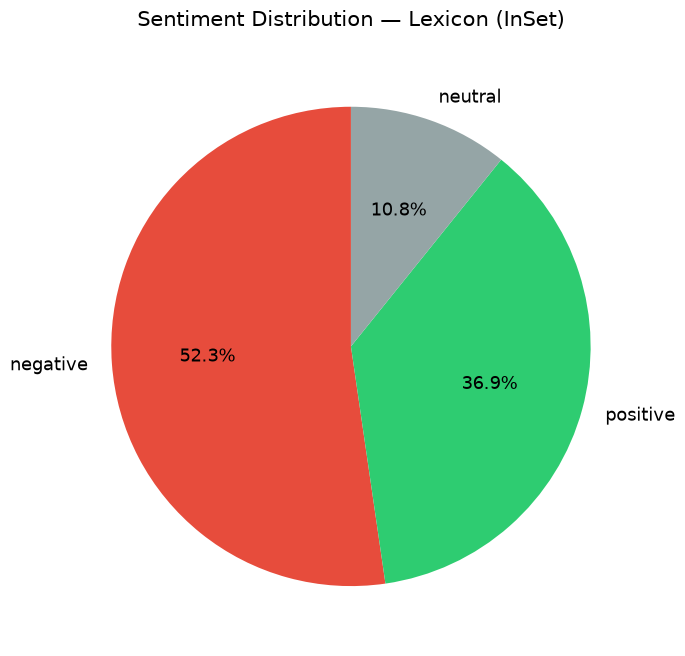

In [18]:
import matplotlib.pyplot as plt

warna = {'negative':'#e74c3c', 'neutral':'#95a5a6', 'positive':'#2ecc71'}

vc = df['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    vc.to_numpy(),
    labels=vc.index.tolist(),
    autopct="%1.1f%%",
    colors=[warna[i] for i in vc.index],
    textprops={"fontsize": 13},
    startangle=90,
)

ax.set_title('Sentiment Distribution — Lexicon (InSet)', fontsize=15, pad=15)

plt.tight_layout()
plt.show()

In [19]:
pd.set_option('display.max_colwidth', 3000)

def sentimen_lookup(label, n=5):
    sub = df[df['sentiment'] == label]
    sub = sub[['content', 'text_finally_clean', 'polarity_score', 'sentiment']]
    sub = sub.reindex(sub['polarity_score'].abs().sort_values(ascending=False).index)
    sub = sub.reset_index(drop=True)
    sub.index += 1
    return sub.head(n)

positive_reviews = sentimen_lookup('positive')
negative_reviews = sentimen_lookup('negative')

In [20]:
positive_reviews

,content,text_finally_clean,polarity_score,sentiment
1,"transaksi sangat mudah dan aman, tolong tambahkan detail history transaksi supaya mudah dalam pengecekan setiap transaksinya, dan tambahkan setting alamat email supaya bisa diganti untuk kemudahan riwayat transaksi, terima kasih 👍👍👍",transaksi mudah aman tolong tambah detail history transaksi mudah kece transaksi tambah atur alamat email ganti mudah riwayat transaksi terima kasih jempol,43.0,positive
2,"excellent.. one stop financial 👍🏻👍🏻👍🏻 hanya dg 1 aplikasi ini semua menjadi mudah spt bill payment pra/pasca, transaksi finansial sesama dan antar bank tanpa biaya/free, top up transportasi ol, berlimpah point, bonus saldo dsb, many thanks SiMobi Plus 😍😘",excellent one stop financial jempol warna kulit cerah jempol warna kulit cerah jempol warna kulit cerah dg mudah bill payment pra pasca transaksi finansial biaya free top transportasi online limpah point bonus saldo many terima kasih plus wajah senyum lebar mata hati wajah cium,35.0,positive
3,Sangat membantu dan memudahkan dalam transaksi...good job. Terimakasih Bank Sinarmas. Saya sudah mendapatkan Undian HIP HIP HORAI....saya pemenang ke 2. Di undian itu dan sudah diterima Hadiahnya yg dikirim Alfatrex...makasih..💖👍👍🙏,bantu mudah transaksi good job terima kasih sinarmas undi hip hip horai menang undi terima hadiah kirim alfatrex terima kasih hati sinar jempol lipat tangan,26.0,positive
4,Tingkatkan lagi apl'y.. tolong pengUpdatean no tlfn untuk verifikasi di selaraskan dgn bank secepatnya.. karna sudah beberapa bulan yang lalu sya update no baru namun saat transaksi kirim kerekening baru harus melalui verifiksi kno tlfn tp knp kirim kode verifikasinya ttp ke no tlfn lma.. tolong lah untuk update sesuai data bank lebih ditingkatkan lgy agar lebih mempermudah nasabah dlm bertransaksi. Tks,tingkat apl tolong pengupdatean tlfn verifikasi selaras cepat transaksi kirim rekening verifiksi kno tlfn kirim kode verifikasi tlfn lma tolong sesuai data tingkat lgy mudah nasabah dlm transaksi terima kasih,26.0,positive
5,Sangat membantu dan mudah dalam bertransaksi. Hanya saja jika baru pertama kali transaksi ke rekening lain harus mendapatkan kode OTP (berbayar pulsa). Terkadang kendala jaringan sehingga kode OTP nya terlambat. Jika tanpa OTP lebih mudah lagi dalam bertransaksi pertama ke rekening lain. Semoga ada pembaharuan yang makin mempermudah bertransaksi 🙏🏻 Terimakasih,bantu mudah transaksi kali transaksi rekening kode otp bayar pulsa terkadang kendala jaring kode otp lambat otp mudah transaksi rekening moga baharu mudah transaksi lipat tangan warna kulit cerah terima kasih,25.0,positive


In [21]:
negative_reviews

,content,text_finally_clean,polarity_score,sentiment
1,"bagaimana sih simobi? mau pindah hp ke hp lain, tapi pas masukkan kode otp malah di bilang salah masukkan lebih dari 3x. padahal udah dari di ketik sampai salin, masih aja salah kode otp katanya. terakhir suruh coba lagi setelah 24 jam, kalau dari awal suruh hubungi call center ga usah acara Minta kode otp, dan pulsa harus ada. ternyata yg salah server ya, pertama minta kode ga di kirim, pas kirim ulang salah kode pas masuk. trnyata telat kode ya, masuk setelah salah baru masuk kode ke 2 🙂‍↕️",pindah pas masuk kode otp bilang salah masuk ketik salin salah kode otp suruh coba jam suruh hubung call center ga acara kode otp pulsa salah server kode ga kirim pas kirim ulang salah kode pas masuk trnyata lambat kode masuk salah masuk kode kepala angguk,-55.0,negative
2,"Sumpahhhh aplikasinya buruk banget deh👎dikit* minta perbarui, mau login aja susah banget, pin udah dimasukin masih aja gagal.. Uninstal, lagipula banyak komen yang jelek juga.. Kenapa minta di perbarui terus ya aplikasinya.. Jadi gak nyaman pakainya. Setiap buka muncul diperbarui terus. Tolong dong ditingkat kan lagi. Masa mbhankingnya dikit* minta perbarui. Perbarui kan gak berkali* gitu, aku aja yang bni gak setiap saat minta perbarui.",sumpahh aplikasi buruk banget deh jempol dikit baru login susah banget pin dimasukin gagal uninstal lagipula jelek baru aplikasi tidak nyaman pakai buka muncul baru tolong tingkat mbhankingnya dikit baru baru tidak kali bni tidak baru,-46.0,negative
3,KSP SAMPAAAH Daftar jah susaah bangeeet ftoh wajah selalu ggal di ulaanf 100 x ttep ja TDK BS di kirim..mending TDK usah pasang di playstore..TDK usah posting2 di FB..di ajukan nyatanya selalu faileed..tutup ja TDK usah buka...dasar KSP sampah TDK BS mlayani Nasabah bikin emosi saja,ksp sampaah daftar jah susaah bangeet ftoh wajah ggal ulaanf ttep tidak kirim mending tidak pasang playstore tidak posting fb aju faileed tutup tidak buka dasar ksp sampah tidak mlayani nasabah bikin emosi,-46.0,negative
4,"Saya apply kartu kredit menggunakan aplikasi ini selalu ditolak dan tidak ada keterangan perihal apa penolakannya, padahal di bank lain pengajuan saya di acc.silakan cek riwayat kredit saya di BI checking, baik atau buruk.sudah capek2 isi data-data lengkap, eh ujung2nya ditolak pengajuan saya, bukan cuma sekali tapi sudah 3 kali ditolak.mengecewakan sekali.",apply kartu kredit tolak tidak terang perihal tolak aju acc sila cek riwayat kredit bi checking buruk capek isi data data lengkap eh ujung tolak aju bukan kali tolak kecewa,-46.0,negative
5,"Stupid Apps! Mau topup ewallet minta otp, pas dimasukkan otp malah invalid. Dicoba lagi tiga kali tetap saja invalid. alhasil akun di BLOCK! Udah mau topup ewallet kena 2K, kode otp kena biaya pula. Eh kode otp invalid akun di-block! Males lah urus urus ke cabang terdekat mending uninstall aja! Gak pake lagi Kapok",stupid apps topup ewallet otp pas masuk otp invalid coba kali invalid alhasil akun block topup ewallet kena kode otp kena biaya eh kode otp invalid akun block males urus urus cabang dekat mending uninstall tidak pakai kapok,-44.0,negative


### Wordcloud Category

In [22]:
%pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


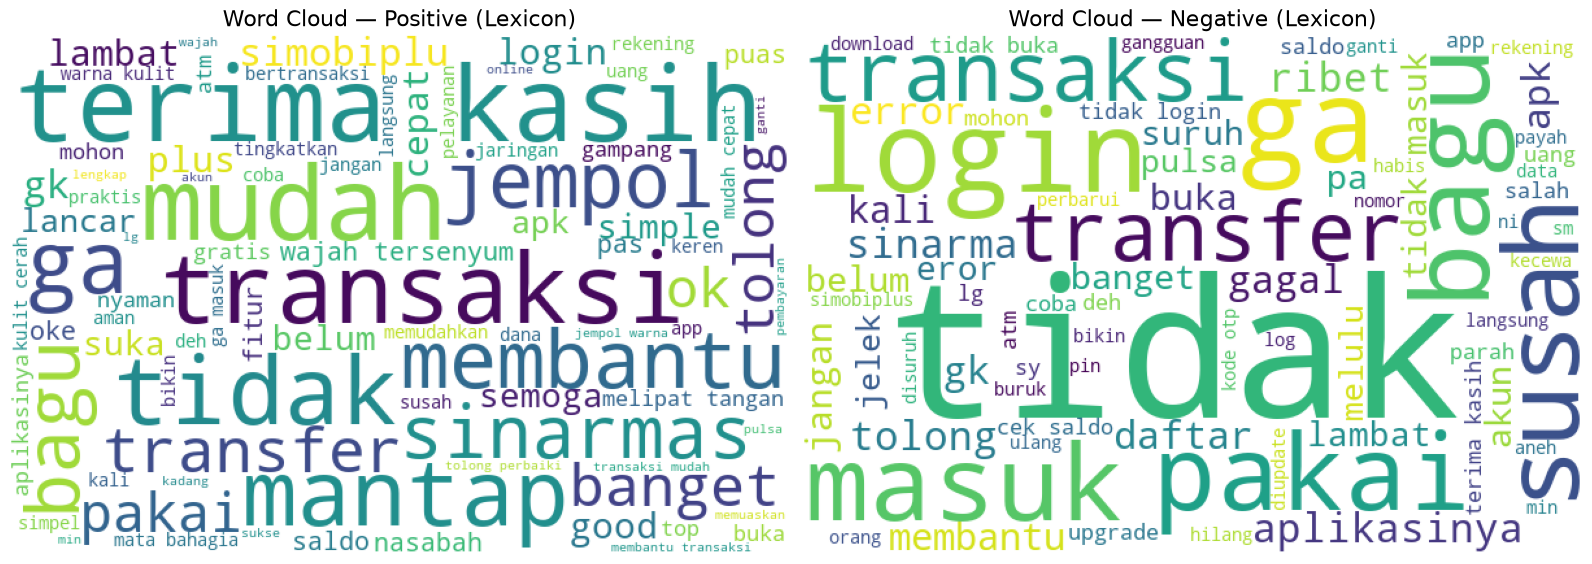

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

labels = ['positive', 'negative']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label in zip(axes, labels):
    sub = df[df['sentiment'] == label]
    teks = ' '.join(' '.join(toks) for toks in sub['text_stopword'])

    wc = WordCloud(width=600, height=400, background_color='white',
                   min_font_size=10).generate(teks)

    ax.imshow(wc)
    ax.set_title(f'Word Cloud — {label.capitalize()} (Lexicon)', fontsize=16)
    ax.axis('off')

fig.tight_layout(pad=1)
plt.show()

### Chart

In [24]:
%pip install seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


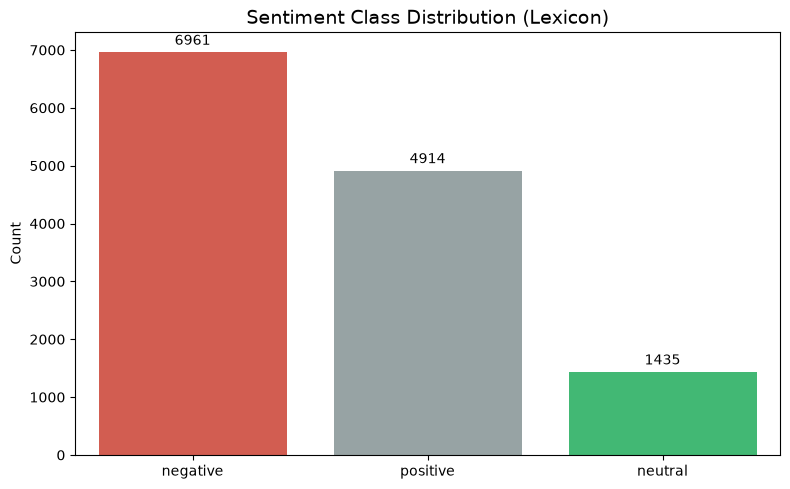

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

warna = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
LABEL = "sentiment"

order = df[LABEL].value_counts().index

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    x=LABEL,
    data=df,
    order=order,
    palette=[warna[l] for l in order],
    hue=LABEL,
    legend=False,
    ax=ax,
)

ax.set_title("Sentiment Class Distribution (Lexicon)", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Count")

for p in ax.patches:
    if isinstance(p, Rectangle):
        ax.annotate(
            f"{p.get_height():.0f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

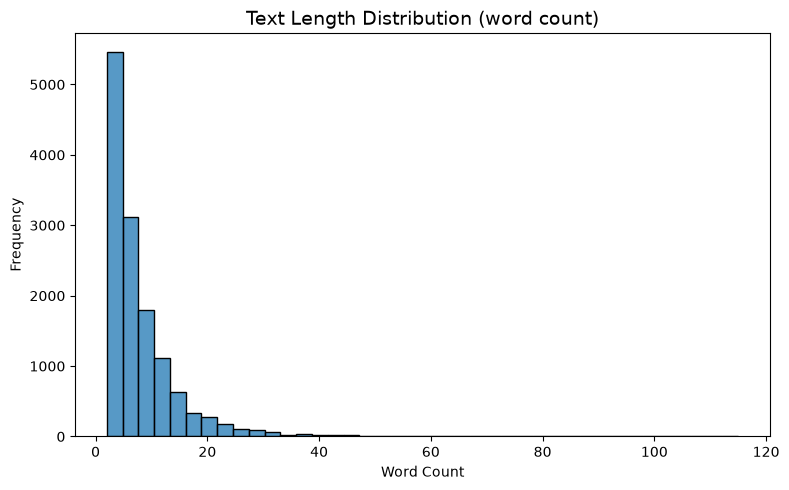

In [26]:
df["text_length"] = df["text_finally_clean"].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(x="text_length", data=df, bins=40, ax=ax)
ax.set_title("Text Length Distribution (word count)", fontsize=14)
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

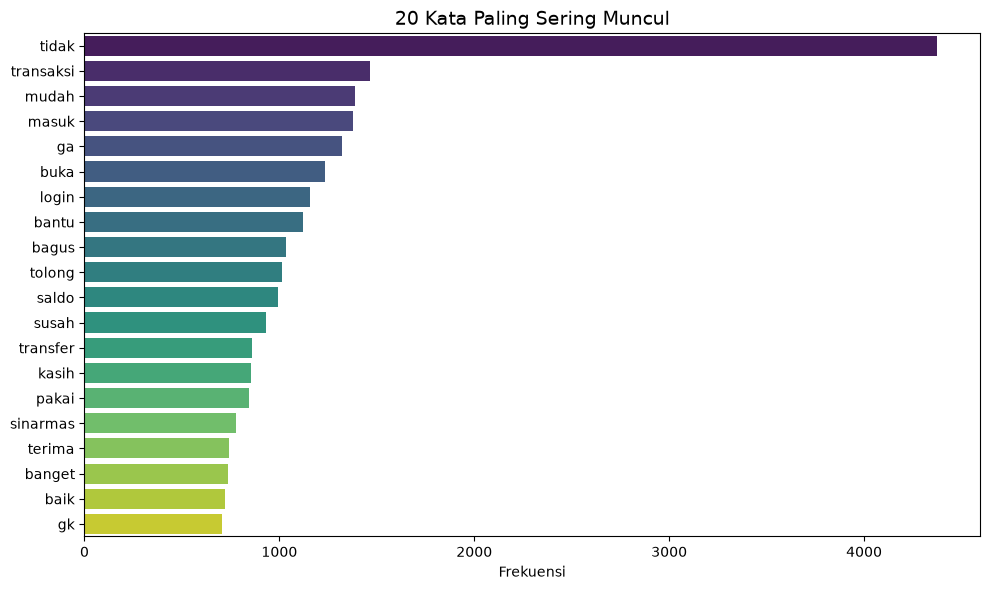

In [27]:
import numpy as np

from typing import cast
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cast(csr_matrix, cv.fit_transform(df["text_finally_clean"]))
freq = np.asarray(X.sum(axis=0)).flatten()

freq_df = (pd.DataFrame({'word': cv.get_feature_names_out(), 'count': freq}).sort_values('count', ascending=False).head(20))

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='word', data=freq_df, hue='word', palette='viridis', legend=False)
plt.title('20 Kata Paling Sering Muncul', fontsize=14)
plt.xlabel('Frekuensi'); plt.ylabel('')
plt.tight_layout(); plt.show()

## Data Splitting

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

X = df_bin['text_finally_clean']
y = df_bin['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=15000, min_df=2, max_df=0.9, ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

Accuracy: 0.827
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1392
           1       0.86      0.69      0.77       983

    accuracy                           0.83      2375
   macro avg       0.84      0.81      0.82      2375
weighted avg       0.83      0.83      0.82      2375



## Training Model

### Model Naive Bayes

In [29]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

naive_bayes = BernoulliNB()
naive_bayes.fit(X_train, y_train)

y_pred_train = naive_bayes.predict(X_train)
y_pred_test  = naive_bayes.predict(X_test)

accuracy_train_nb = accuracy_score(y_train, y_pred_train)
accuracy_test_nb  = accuracy_score(y_test,  y_pred_test)

print('Naive Bayes - accuracy train:', round(accuracy_train_nb, 3))
print('Naive Bayes - accuracy test :', round(accuracy_test_nb, 3))
print('\n', classification_report(y_test, y_pred_test))

Naive Bayes - accuracy train: 0.853
Naive Bayes - accuracy test : 0.804

               precision    recall  f1-score   support

           0       0.86      0.80      0.83      1392
           1       0.74      0.81      0.78       983

    accuracy                           0.80      2375
   macro avg       0.80      0.81      0.80      2375
weighted avg       0.81      0.80      0.81      2375



### Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

random_forest = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
random_forest.fit(X_train, y_train)

y_pred_train = random_forest.predict(X_train)
y_pred_test  = random_forest.predict(X_test)

accuracy_train_rf = accuracy_score(y_train, y_pred_train)
accuracy_test_rf  = accuracy_score(y_test,  y_pred_test)

print('Random Forest - accuracy train:', round(accuracy_train_rf, 3))
print('Random Forest - accuracy test :', round(accuracy_test_rf, 3))
print('\n', classification_report(y_test, y_pred_test))

Random Forest - accuracy train: 1.0
Random Forest - accuracy test : 0.859

               precision    recall  f1-score   support

           0       0.85      0.93      0.89      1392
           1       0.88      0.76      0.82       983

    accuracy                           0.86      2375
   macro avg       0.86      0.84      0.85      2375
weighted avg       0.86      0.86      0.86      2375



### Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logistic_regression = LogisticRegression(C=10, class_weight="balanced", max_iter=3000)
logistic_regression.fit(X_train, y_train)

y_pred_train = logistic_regression.predict(X_train)
y_pred_test  = logistic_regression.predict(X_test)

accuracy_train_lr = accuracy_score(y_train, y_pred_train)
accuracy_test_lr  = accuracy_score(y_test,  y_pred_test)

print('Logistic Regression - accuracy train:', round(accuracy_train_lr, 3))
print('Logistic Regression - accuracy test :', round(accuracy_test_lr, 3))
print('\n', classification_report(y_test, y_pred_test))

Logistic Regression - accuracy train: 0.987
Logistic Regression - accuracy test : 0.89

               precision    recall  f1-score   support

           0       0.91      0.90      0.91      1392
           1       0.86      0.87      0.87       983

    accuracy                           0.89      2375
   macro avg       0.89      0.89      0.89      2375
weighted avg       0.89      0.89      0.89      2375



### Decision Tree

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

y_pred_train = decision_tree.predict(X_train)
y_pred_test  = decision_tree.predict(X_test)

accuracy_train_dt = accuracy_score(y_train, y_pred_train)
accuracy_test_dt  = accuracy_score(y_test,  y_pred_test)

print('Decision Tree - accuracy train:', round(accuracy_train_dt, 3))
print('Decision Tree - accuracy test :', round(accuracy_test_dt, 3))
print('\n', classification_report(y_test, y_pred_test))

Decision Tree - accuracy train: 1.0
Decision Tree - accuracy test : 0.843

               precision    recall  f1-score   support

           0       0.87      0.86      0.87      1392
           1       0.81      0.81      0.81       983

    accuracy                           0.84      2375
   macro avg       0.84      0.84      0.84      2375
weighted avg       0.84      0.84      0.84      2375



### Linear SVM

In [33]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

linear_svc = LinearSVC(max_iter=10000, random_state=42)
linear_svc.fit(X_train, y_train)

y_pred_train = linear_svc.predict(X_train)
y_pred_test  = linear_svc.predict(X_test)

print('Linear SVM - accuracy train:', round(accuracy_score(y_train, y_pred_train), 3))
print('Linear SVM - accuracy test :', round(accuracy_score(y_test,  y_pred_test), 3))
print('\n', classification_report(y_test, y_pred_test))

Linear SVM - accuracy train: 0.989
Linear SVM - accuracy test : 0.892

               precision    recall  f1-score   support

           0       0.90      0.92      0.91      1392
           1       0.88      0.86      0.87       983

    accuracy                           0.89      2375
   macro avg       0.89      0.89      0.89      2375
weighted avg       0.89      0.89      0.89      2375



### Grid Search for Tuning Parameter

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

def tune_and_report(estimator, param_grid, name):
    grid = GridSearchCV(estimator, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)

    print(f'=== {name} ===')
    print('Best params :', grid.best_params_)
    print('Best CV f1  :', round(grid.best_score_, 3))

    best = grid.best_estimator_
    y_pred_train = best.predict(X_train)
    y_pred_test  = best.predict(X_test)
    print('Acc train   :', round(accuracy_score(y_train, y_pred_train), 3))
    print('Acc test    :', round(accuracy_score(y_test,  y_pred_test), 3))
    print(classification_report(y_test, y_pred_test))
    return grid.best_estimator_

lr_best = tune_and_report(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    {'C': [0.1, 1, 5, 10]},
    'Logistic Regression')

svc_best = tune_and_report(
    LinearSVC(max_iter=10000, random_state=42, class_weight='balanced'),
    {'C': [0.3, 0.5, 1, 2, 5]},
    'Linear SVM')

nb_best = tune_and_report(
    MultinomialNB(),
    {'alpha': [0.1, 0.5, 1.0, 2.0]},
    'Naive Bayes')

dt_best = tune_and_report(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    {'max_depth': [30, 50, None], 'min_samples_split': [2, 10]},   # 6 kombinasi
    'Decision Tree')

rf_best = tune_and_report(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    {'n_estimators': [200], 'max_depth': [50, None]},   # 2 kombinasi saja
    'Random Forest')

=== Logistic Regression ===
Best params : {'C': 10}
Best CV f1  : 0.885
Acc train   : 0.987
Acc test    : 0.89
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1392
           1       0.86      0.87      0.87       983

    accuracy                           0.89      2375
   macro avg       0.89      0.89      0.89      2375
weighted avg       0.89      0.89      0.89      2375

=== Linear SVM ===
Best params : {'C': 1}
Best CV f1  : 0.883
Acc train   : 0.989
Acc test    : 0.887
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1392
           1       0.86      0.87      0.86       983

    accuracy                           0.89      2375
   macro avg       0.88      0.88      0.88      2375
weighted avg       0.89      0.89      0.89      2375

=== Naive Bayes ===
Best params : {'alpha': 0.5}
Best CV f1  : 0.823
Acc train   : 0.889
Acc test    : 0.829
              precision 

## Summary Model

In [35]:
from sklearn.metrics import f1_score

models = {
    'Logistic Regression': lr_best,
    'Linear SVC':          svc_best,
    'Naive Bayes':         nb_best,
    'Decision Tree':       dt_best,
    'Random Forest':       rf_best,
}

results_df = (pd.DataFrame([
    {
        'Model': name,
        'Acc Train': accuracy_score(y_train, m.predict(X_train)),
        'Acc Test':  accuracy_score(y_test,  m.predict(X_test)),
        'F1-macro Test': f1_score(y_test, m.predict(X_test), average='macro'),
    }
    for name, m in models.items()
])
.round(3)
.sort_values('F1-macro Test', ascending=False)
.reset_index(drop=True))

print(results_df)

                 Model  Acc Train  Acc Test  F1-macro Test
0  Logistic Regression      0.987     0.890          0.887
1           Linear SVC      0.989     0.887          0.883
2        Random Forest      1.000     0.856          0.849
3        Decision Tree      1.000     0.837          0.832
4          Naive Bayes      0.889     0.829          0.818


## Confusion Matrix Logistic Regression

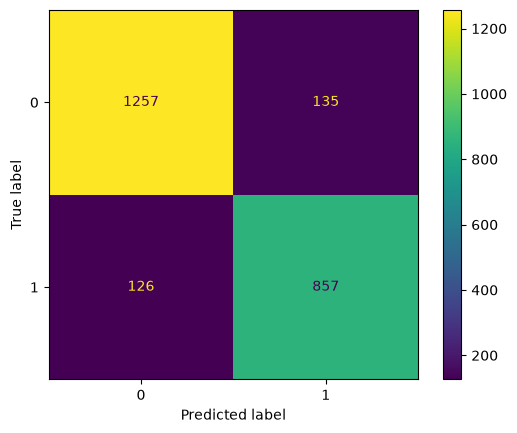

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr_best, X_test, y_test)

## Save Model

In [37]:
%pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import joblib

joblib.dump(lr_best, "../models/lr_sentiment.pkl")
joblib.dump(tfidf, "../models/tfidf.pkl")

['../models/tfidf.pkl']

## Prediction with Model

In [39]:
def feature_extraction(kalimat):
    text_clean = cleaning_text(convert_emoji(kalimat))
    tokens = filtering_stopwords(
                tokenizing_text(
                    fix_slangwords(
                        normalize_elongation(
                            case_folding_text(text_clean)))))
    tokens = stemming_text(tokens)
    text_final = to_sentence(tokens)

    X = tfidf.transform([text_final])
    return X, text_final

In [40]:
LABEL_MAP = {0: 'negative', 1: 'positive'}

def sentiment_prediction(text):
    X_new, text_final = feature_extraction(text)

    pred_lr  = lr_best.predict(X_new)[0]
    pred_svc = svc_best.predict(X_new)[0]

    proba = lr_best.predict_proba(X_new)[0]
    conf  = dict(zip(lr_best.classes_, proba))

    print(f'Kalimat        : {text}')
    print(f'Teks bersih    : {text_final}')
    print('-' * 55)
    print(f'  Logistic Regression : {LABEL_MAP[pred_lr].upper():8s} (confidence {conf[pred_lr]*100:.1f}%)')
    print(f'  Linear SVC          : {LABEL_MAP[pred_svc].upper()}')
    print('=' * 55)
    return LABEL_MAP[pred_lr], LABEL_MAP[pred_svc]

print(sentiment_prediction('aplikasi error terus tidak bisa login'))
print(sentiment_prediction('transaksi cepat dan mudah sekali'))

Kalimat        : aplikasi error terus tidak bisa login
Teks bersih    : error tidak login
-------------------------------------------------------
  Logistic Regression : NEGATIVE (confidence 99.9%)
  Linear SVC          : NEGATIVE
('negative', 'negative')
Kalimat        : transaksi cepat dan mudah sekali
Teks bersih    : transaksi cepat mudah
-------------------------------------------------------
  Logistic Regression : POSITIVE (confidence 99.9%)
  Linear SVC          : POSITIVE
('positive', 'positive')


In [41]:
print(sentiment_prediction(
    'aplikasi ini sangat mengecewakan sering error saat login transaksi gagal '
    'terus padahal saldo sudah terpotong tolong segera diperbaiki karena sangat '
    'mengganggu dan bikin susah'))

Kalimat        : aplikasi ini sangat mengecewakan sering error saat login transaksi gagal terus padahal saldo sudah terpotong tolong segera diperbaiki karena sangat mengganggu dan bikin susah
Teks bersih    : kecewa error login transaksi gagal saldo potong tolong baik ganggu bikin susah
-------------------------------------------------------
  Logistic Regression : NEGATIVE (confidence 99.8%)
  Linear SVC          : NEGATIVE
('negative', 'negative')


In [42]:
print(sentiment_prediction(
    'sejauh ini aplikasinya sangat membantu transaksi cepat tampilan mudah '
    'dipahami fitur transfer dan cek saldo lancar tanpa kendala terima kasih '
    'sudah terus melakukan update yang bagus'))

Kalimat        : sejauh ini aplikasinya sangat membantu transaksi cepat tampilan mudah dipahami fitur transfer dan cek saldo lancar tanpa kendala terima kasih sudah terus melakukan update yang bagus
Teks bersih    : aplikasi bantu transaksi cepat tampil mudah paham fitur transfer cek saldo lancar kendala terima kasih bagus
-------------------------------------------------------
  Logistic Regression : POSITIVE (confidence 84.0%)
  Linear SVC          : POSITIVE
('positive', 'positive')


In [43]:
print(sentiment_prediction(
    'aplikasinya bagus dan fiturnya lengkap tapi sayang sering lemot saat dibuka '
    'dan kadang gagal login jadi agak mengganggu walaupun secara keseluruhan '
    'masih cukup membantu'))

Kalimat        : aplikasinya bagus dan fiturnya lengkap tapi sayang sering lemot saat dibuka dan kadang gagal login jadi agak mengganggu walaupun secara keseluruhan masih cukup membantu
Teks bersih    : aplikasi bagus fiturnya lengkap sayang lambat buka kadang gagal login ganggu bantu
-------------------------------------------------------
  Logistic Regression : NEGATIVE (confidence 99.1%)
  Linear SVC          : NEGATIVE
('negative', 'negative')
